# Homework 2: Creating a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg')

In [162]:
import pandas as pd
import numpy as np

In [163]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [164]:
!wget $data 

--2026-10-04 17:05:13--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.4’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.1s    

2026-10-04 17:05:13 (5.84 MB/s) - ‘car_fuel_efficiency_2026.csv.4’ saved [635180/635180]



In [165]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [166]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Columns Used:'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg'

In [167]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]
target = "fuel_efficiency_mpg"

In [168]:
df = df[features + [target]].copy()
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [169]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

## Exploratory data analysis

In [170]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

model_year
[2006 2008 1996 1989 1994]
50

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



# Distribution of fuel_efficiency_mpg

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
# Forces plots to be created inline, although some Jupyter environment do this by default.
%matplotlib inline 

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

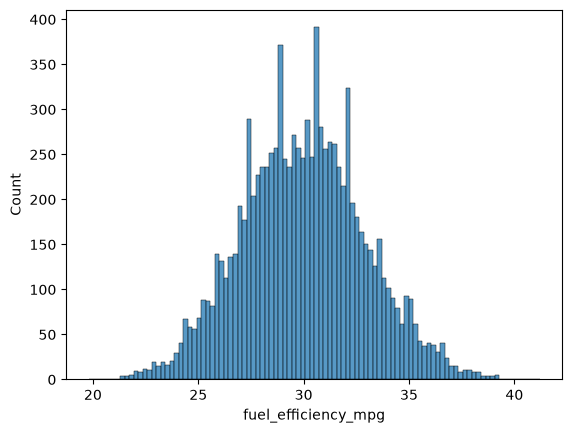

In [172]:
sns.histplot(df.fuel_efficiency_mpg, bins=100)

### [Question 1]
- There's one column with missing values. What is it?

In [173]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### [Question 2]
- What's the median (50% percentile) for variable 'horsepower'?

In [174]:
df["horsepower"].median()

np.float64(254.0)

In [175]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test # leave the remainder in the training dataset

In [176]:
n

10000

In [177]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [178]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,NaN,4150,1997
4521,2340,269.0,4400,2001


In [179]:
np.random.seed(42) # specifies the seed to it is reproducible
idx = np.arange(n) # Creates sequence of numbers
np.random.shuffle(idx) # Shuffles the sequence

In [180]:
# Data cut with the randomized sequence
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [181]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [182]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

In [183]:
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

### [Question 3]
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

#### Fill Missing Values with 0

In [184]:
df_train_0 = df_train.fillna(0)
df_train_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [185]:
df_val_0 = df_val.fillna(0)
df_val_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [186]:
X_train_0 = df_train_0.values
X_val_0 = df_val_0.values

In [187]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [188]:
X_train_0 = df_train_0.values
X_val_0 = df_val_0.values

In [189]:
w0, w = train_linear_regression(X_train_0, y_train)

In [190]:
y_pred = w0 + X_val_0.dot(w)

In [191]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()

    return np.sqrt(mse)

In [192]:
score_0 = rmse(y_val, y_pred)
score_0.round(3)

np.float64(2.205)

#### Fill Missing Values with mean

In [193]:
mean_value = df_train["horsepower"].mean()
mean_value

np.float64(254.46338337605272)

In [194]:
df_train_mean = df_train.fillna(mean_value)
df_train_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [195]:
df_val_mean = df_val.fillna(mean_value)
df_val_mean.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [196]:
X_train_mean = df_train_mean.values
X_val_mean = df_val_mean.values

In [197]:
w0, w = train_linear_regression(X_train_mean, y_train)

In [198]:
y_pred = w0 + X_val_mean.dot(w)

In [199]:
score_mean = rmse(y_val, y_pred)
score_mean.round(3)

np.float64(2.202)

In [200]:
score_0.round(3) - score_mean.round(3)

np.float64(0.0030000000000001137)

Filling missing values with the mean produced a lower / better validation RMSE

### [Question 4]
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

In [211]:
df_train_0.head()

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,0.0,4150,1997
4521,2340,269.0,4400,2001


In [212]:
df_val_0.iloc[20:25]

,engine_displacement,horsepower,vehicle_weight,model_year
8768,2340,0.0,4130,1983
4207,2230,254.0,4080,2006
3218,2310,240.0,4350,1976
1391,2090,250.0,3840,1996
3975,2540,302.0,4800,2013


In [213]:
X_train = df_train_0.values
X_val = df_val_0.values

In [214]:
def train_linear_regression_reg(X, y, r=0.001):
    # Add a column of 1s for the bias term (w0)
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Calculate the Gram matrix
    XTX = X.T.dot(X)
    
    # Add 'r' to the main diagonal. The larger 'r' is, the smaller the values in the inverse, giving us more control over the weights.
    XTX = XTX + r * np.eye(XTX.shape[0])

    # Compute the inverse and the final weights (now safe from multicollinearity)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    # Return bias (w0) and weights (w) separately
    return w_full[0], w_full[1:]

In [219]:
results = []
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    # Train the model using the current value of 'r' to get our bias (w0) and weights (w)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    # Generate price predictions on the validation set using the trained weights
    y_pred = w0 + X_val.dot(w)
    
    # Calculate the RMSE to see how accurate the model is with this specific 'r' value
    score = rmse(y_val, y_pred)
    
    results.append((r, w0, score))
results

[(0, np.float64(-153.88496188223104), np.float64(2.205293194751098)),
 (0.01, np.float64(-148.3092124404723), np.float64(2.205827616672006)),
 (0.1, np.float64(-111.83871039307081), np.float64(2.2241432777850636)),
 (1, np.float64(-32.331865964969374), np.float64(2.349228888392786)),
 (5, np.float64(-7.772852209978469), np.float64(2.409380166599679)),
 (10, np.float64(-3.987116416019025), np.float64(2.4194698654732387)),
 (100, np.float64(-0.4082196488463344), np.float64(2.4292021380162367))]

In [223]:
sorted_results = sorted(results, key=lambda x: x[2])
for r, w0, score in sorted_results:
    print(r, w0, score)

0 -153.88496188223104 2.205293194751098
0.01 -148.3092124404723 2.205827616672006
0.1 -111.83871039307081 2.2241432777850636
1 -32.331865964969374 2.349228888392786
5 -7.772852209978469 2.409380166599679
10 -3.987116416019025 2.4194698654732387
100 -0.4082196488463344 2.4292021380162367


The best validation RMSE was achieved with `r = 0`

### [Question 5]
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

What's the value of std?

In [224]:
scores = []

for seed in range(10):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    y_train = df_train[target].values
    y_val = df_val[target].values

    del df_train[target]
    del df_val[target]
    del df_test[target]

    df_train = df_train.fillna(0)
    df_val = df_val.fillna(0)

    X_train = df_train.values
    X_val = df_val.values

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    scores.append(score)

    print(seed, score)
scores

0 2.2392041430461465
1 2.2021128210838907
2 2.163419778753095
3 2.2043588768539144
4 2.2018800943312926
5 2.2457851509084974
6 2.269721207952404
7 2.190794599933433
8 2.2166112016864443
9 2.207036592817851


[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [225]:
std = np.std(scores)

round(std, 3)

np.float64(0.029)

### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [230]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

df_train_full = pd.concat([df_train, df_val])

y_train_full = df_train_full[target].values
y_test = df_test[target].values

del df_train_full[target]
del df_test[target]

df_train_full = df_train_full.fillna(0)
df_test = df_test.fillna(0)

X_train_full = df_train_full.values
X_test = df_test.values

w0, w = train_linear_regression_reg(
    X_train_full,
    y_train_full,
    r=0.001
)

y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

score.round(3)

np.float64(2.236)